# Bussed Ramsey calibration Functions 

[np.float64(0.7055654651527067), np.float64(0.04421185245779348), np.float64(0.29443453485551396)]


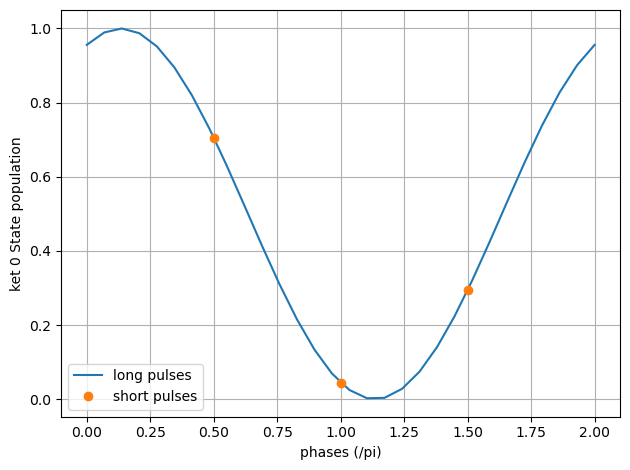

In [ ]:
import numpy as np
from scipy.linalg import expm
import io
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
def load_line_fit_parameters(filename):
    B0_fit = None
    B0_err = None
    harmonic_lines = []
    with open(filename, "r") as f:
        for line in f:
            stripped = line.strip()
            if not stripped or stripped.startswith("#"):
                continue
            if B0_fit is None:
                vals = np.fromstring(stripped, sep=" ")
                B0_fit, B0_err = vals[0], vals[1]
            else:
                harmonic_lines.append(stripped)
    harmonics = np.loadtxt(io.StringIO("\n".join(harmonic_lines)))
    if harmonics.ndim == 1:
        harmonics = harmonics[None, :]
    freqs = harmonics[:, 0]
    A_vals = harmonics[:, 1]
    A_errs = harmonics[:, 2]
    phi_vals = harmonics[:, 3]
    phi_errs = harmonics[:, 4]
    return B0_fit, B0_err, freqs, A_vals, A_errs, phi_vals, phi_errs
    
def _get_line_params(param_file, B0, A60, phi60, A180, phi180):
    if param_file is not None:
        B0_fit, B0_err, freqs, A_vals, A_errs, phi_vals, phi_errs = load_line_fit_parameters(param_file)
        return B0_fit, freqs, A_vals, phi_vals
    freqs = np.array([60.0, 180.0], dtype=float)
    A_vals = np.array([A60, A180], dtype=float)
    phi_vals = np.array([phi60, phi180], dtype=float)
    return B0, freqs, A_vals, phi_vals


def B_line_mG(t, B0=0.2289, A60=-0.2791, phi60=1.0002, A180=-0.0774, phi180=-0.2650, param_file = 'Z:\Lab Data\Line_signal_fitted_params\line_signal_fit_params.txt'):
    B0_use, freqs, A_vals, phi_vals = _get_line_params(param_file, B0, A60, phi60, A180, phi180)
    t_arr = np.asarray(t, dtype=float)
    y = np.full_like(t_arr, B0_use, dtype=float)
    for f, A, phi in zip(freqs, A_vals, phi_vals):
        y = y + A * np.cos(2.0 * np.pi * f * t_arr + phi)
    return y

def B_rel_G(t, B0=0.2289, A60=-0.2791, phi60=1.0002, A180=-0.0774, phi180=-0.2650, param_file = 'Z:\Lab Data\Line_signal_fitted_params\line_signal_fit_params.txt'):
    return (
        B_line_mG(t, B0, A60, phi60, A180, phi180, param_file=param_file)
        - B_line_mG(0.0, B0, A60, phi60, A180, phi180, param_file=param_file)
    ) * 1e-3

def primitive_B_rel_G(t, B0=0.2289, A60=-0.2791, phi60=1.0002, A180=-0.0774, phi180=-0.2650, param_file = 'Z:\Lab Data\Line_signal_fitted_params\line_signal_fit_params.txt'):
    B0_use, freqs, A_vals, phi_vals = _get_line_params(param_file, B0, A60, phi60, A180, phi180)
    t_arr = np.asarray(t, dtype=float)
    t_arr_1d = np.atleast_1d(t_arr)
    omega = 2.0 * np.pi * freqs

    B_line_0 = B0_use + np.sum(A_vals * np.cos(phi_vals))
    const_term = (B0_use - B_line_0) * t_arr_1d
    sin_terms = (A_vals / omega)[:, None] * np.sin(omega[:, None] * t_arr_1d[None, :] + phi_vals[:, None])

    F_mG = const_term + np.sum(sin_terms, axis=0)
    F_Gs = 1e-3 * F_mG
    if np.isscalar(t):
        return float(F_Gs[0])
    return F_Gs

def integral_B_rel_G(t_start, t_end, B0=0.2289, A60=-0.2791, phi60=1.0002, A180=-0.0774, phi180=-0.2650, param_file = 'Z:\Lab Data\Line_signal_fitted_params\line_signal_fit_params.txt'):
    F_end = primitive_B_rel_G(t_end, B0, A60, phi60, A180, phi180, param_file=param_file)
    F_start = primitive_B_rel_G(t_start, B0, A60, phi60, A180, phi180, param_file=param_file)
    return F_end - F_start

def get_pulse_schedule(rabi_freqs, fractions):
    if len(rabi_freqs) != len(fractions):
        raise ValueError(
            f"rabi_freqs {len(rabi_freqs)} and fractions {len(fractions)} must have the same length."
        )
    times = []
    t_current = 0.0
    for Omega, frac in zip(rabi_freqs, fractions):
        if not 0 <= frac <= 1:
            raise ValueError(f"Fraction must be between 0 and 1, got {frac}.")
        theta = 2.0 * np.arcsin(np.sqrt(frac))
        t_pulse = theta / Omega if Omega > 0 else 0.0
        t_start = t_current
        t_end = t_current + t_pulse
        times.append((t_start, t_end))
        t_current = t_end
    return times

def compute_pi_times(pi_t = [26.374, 38.265, 118.144, 30.527, 38.734]):
    transition_strengths_path=r"Z:\Lab Data\Phase_and_freq_correction_180Hz\Transition_strengths_4p209.txt"
    transition_strengths = np.loadtxt(transition_strengths_path, delimiter=",")
    transition_strengths[transition_strengths == 0] = np.nan
    strengths = np.array(
        [
            transition_strengths[21, 2],
            transition_strengths[14, 0],
            transition_strengths[5, 2],
            transition_strengths[16, 4],
            transition_strengths[15, 4],
        ]
    )
    factors = np.array(pi_t, dtype=float) * strengths

    Fs = [1, 2, 3, 4]
    row_labels = [[i, i - j] for i in Fs for j in range(2 * i + 1)]
    col_labels = [-2, -1, 0, 1, 2]

    pi_times = np.zeros((24, 5), dtype=float)
    for i in range(transition_strengths.shape[0]):
        for j in range(transition_strengths.shape[1]):
            if not np.isnan(transition_strengths[i, j]):
                delta_m = (row_labels[i][1] - col_labels[j]) + 2
                pi_times[i, j] = factors[delta_m] / transition_strengths[i, j]
    return pi_times

def get_pi_times_from_matrix(transitions, matrix):
    Fs = [1, 2, 3, 4]
    states = []
    for i in Fs:
        for j in range(2 * i + 1):
            mF = i - j
            states.append([i, mF])
    row_labels = states
    col_labels = [-2, -1, 0, 1, 2]

    out = []
    for transition in transitions:
        row_label = [transition[1], transition[2]]
        col_label = transition[0]
        row_index = next((k for k, label in enumerate(row_labels) if label == row_label), None)
        col_index = col_labels.index(col_label) if col_label in col_labels else None
        if row_index is not None and col_index is not None:
            out.append(matrix[row_index, col_index])
        else:
            out.append(np.nan)
    return out

def bussed_ramsey_pop0(transition_pair, T, delta, ramsey_phase,  pi_time_refs = [26.374, 38.265, 118.144, 30.527, 38.734], consider_line = False):
    # get sensitivity table
    sensitivities_path=r"Z:\Lab Data\Phase_and_freq_correction_180Hz\sensitivities_4p2079.txt" 
    sens_matrix = np.loadtxt(sensitivities_path, delimiter=",")
    sens_list = get_pi_times_from_matrix(transition_pair, sens_matrix)
    #get - pitimes
    pi_times = get_pi_times_from_matrix(transition_pair, compute_pi_times(pi_t = pi_time_refs))
    #get - sensitivities
    pair_sensitivities = get_pi_times_from_matrix(transition_pair, sens_matrix)

    pi_time_0b = pi_times[0]
    pi_time_b1 = pi_times[1]
    sens_0b = pair_sensitivities[0]
    sens_b1 = pair_sensitivities[1]
    # Rabi frequencies
    omega_0b = np.pi / (pi_time_0b * 1e-6)
    omega_b1 = np.pi / (pi_time_b1 * 1e-6)
    omega_dummy = np.pi/(1)
    t_pi2_0b = (pi_time_0b * 1e-6) / 2
    t_pi_b1 = (pi_time_b1 * 1e-6)

    Ramsey_wait = T * 1e-6
    # get - integral_values
    fractions = [1, 0.5, (np.sin((T/1e6)*(np.pi/2)))**2, 0.5, 1]
    rabi_freqs = [omega_0b, omega_b1, omega_dummy, omega_b1, omega_0b]
    times_seq_for_integral = get_pulse_schedule(rabi_freqs, fractions)
    # print(times_seq_for_integral)
    line_int_values = []
    for slots in times_seq_for_integral:
        if  consider_line:
            line_int_values.append(2.0 * np.pi * 1e6*integral_B_rel_G(slots[0], slots[1]))
        else:
            line_int_values.append(0)
    # print(line_int_values)

    def U_0b(omega, t, phase, delta, line_delta_eq = 0):
        H = np.array([
            [0, omega * np.exp(-1j * phase) / 2, 0],
            [omega * np.exp(1j * phase) / 2, -(delta - (sens_0b*line_delta_eq/t)), 0],
            [0, 0, -(sens_b1*line_delta_eq/t)]
        ], dtype=complex)
        return expm(-1j * H * t)

    def U_b1(omega, t, phase, delta, line_delta_eq = 0):
        H = np.array([
            [0, 0, omega * np.exp(-1j * phase) / 2],
            [0, -(delta - (sens_0b*line_delta_eq/t)), 0],
            [omega * np.exp(1j * phase) / 2, 0, -(sens_b1*line_delta_eq/t)]
        ], dtype=complex)
        return expm(-1j * H * t)

    def U_wait(t, delta, line_delta_eq = 0):
        H = np.array([
            [0, 0, 0],
            [0, -(  delta - (sens_0b*line_delta_eq/t)), 0],
            [0, 0, -(sens_b1*line_delta_eq/t)]
        ], dtype=complex)
        return expm(-1j * H * t)

    # --- Pulse sequence ---
    U1 = U_0b(omega_0b, t_pi2_0b, phase=np.pi, delta=delta, line_delta_eq = line_int_values[0])
    U2 = U_b1(omega_b1, t_pi_b1, phase=0, delta = delta, line_delta_eq = line_int_values[1])
    Uw = U_wait(Ramsey_wait, delta, line_delta_eq = line_int_values[2])
    U3 = U_b1(omega_b1, t_pi_b1, phase=np.pi, delta = delta, line_delta_eq = line_int_values[3])
    U4 = U_0b(omega_0b, t_pi2_0b, phase=np.pi*ramsey_phase, delta=delta, line_delta_eq = line_int_values[4])

    U_total = U4 @ U3 @ Uw @ U2 @ U1

    # Initial state |0>
    ket0 = np.array([0, 1, 0], dtype=complex)

    final_state = U_total @ ket0
    pop0 = np.abs(final_state[1])**2

    return pop0

plt.figure()
phases = np.linspace(0, 2, 30)
pops_list = []
det =  10*2*np.pi
wait_time = 800
for ph in phases:
    pops_list.append(bussed_ramsey_pop0([[0, 4, -2], [0, 2, 0]], wait_time, det, ph, pi_time_refs = [24.17, 38.265, 102.1, 30.527, 38.734], consider_line = True))


pops_list = np.array(pops_list)
# display(pops_list)
plt.plot(phases, pops_list, label = 'long pulses')

det =  10*2*np.pi
wait_time = 800
phase_list = [0.5, 1, 1.5]
ket_data = []
for ph in phase_list:
    ket_data.append(bussed_ramsey_pop0([[0, 4, -2], [0, 2, 0]], wait_time, det, ph, pi_time_refs = [24.17, 38.265, 102.1, 30.527, 38.734], consider_line = True))

print(ket_data)
plt.plot(phase_list, ket_data, 'o', label = 'short pulses')
plt.xlabel('phases (/pi)')
plt.ylabel('ket 0 State population')
plt.grid()
plt.legend()
plt.tight_layout()
plt.show()

In [105]:
from scipy.optimize import curve_fit

def fit_detuning_for_one_dataset(ket_data,
                                 phase_list,
                                 transition_pair,
                                 T_wait_bussed_ramsey,
                                 pi_time_refs =  [24.17, 38.265, 102.1, 30.527, 38.734],
                                 initial_delta_guess=-2 * np.pi * 0, consider_line = True):
    ket_data = np.array(ket_data, dtype=float)

    phase_array = np.array(phase_list, dtype=float)

    if ket_data.shape[0] != phase_array.shape[0]:
        raise ValueError("ket_data and phase_list must have the same length.")



    def ramsey_model(phase_pi, delta):
        return np.array([
            bussed_ramsey_pop0(transition_pair, T_wait_bussed_ramsey, delta, ph, consider_line = consider_line, pi_time_refs = pi_time_refs)
            for ph in phase_pi
        ])

    try:
        params, covariance = curve_fit(
            ramsey_model,
            phase_array,
            ket_data,
            p0=[initial_delta_guess],

            maxfev=5000
        )
        delta_opt = params[0]
        if covariance is not None:
            errors = np.sqrt(np.diag(covariance))
            delta_err = errors[0] if np.isfinite(errors[0]) else None
        else:
            delta_err = None
        return delta_opt, delta_err
    except RuntimeError:
        return None, None

# Uncertainty Calculator

In [127]:
import numpy as np

def detuning_from_ketdata(
    ket_data,
    phase_list,
    transition_pair,
    T_wait_bussed_ramsey,
    pi_time_refs=[26, 38.265, 118, 30.527, 38.734],
    initial_delta_guess=-2*np.pi*0,
    consider_line=True,
):
    delta_opt, delta_err_curvefit = fit_detuning_for_one_dataset(
        ket_data=ket_data,
        phase_list=phase_list,
        transition_pair=transition_pair,
        T_wait_bussed_ramsey=T_wait_bussed_ramsey,
        pi_time_refs=pi_time_refs,
        initial_delta_guess=initial_delta_guess,
        consider_line=consider_line,
    )
    if delta_opt is None:
        raise RuntimeError("Fit failed in detuning_from_ketdata")
    return float(delta_opt)

def sigma_ket_binomial(ket_data, n_shots):
    """
    ket_data: array of r_i in [0,1]
    n_shots: either scalar or array length N
    """
    r = np.asarray(ket_data, dtype=float)
    n = np.asarray(n_shots, dtype=float)
    if n.ndim == 0:
        n = np.full_like(r, n, dtype=float)
    if n.shape != r.shape:
        raise ValueError("n_shots must be scalar or same shape as ket_data")

    # clip away from 0/1 to avoid zero sigma and help finite differences
    r_clip = np.clip(r, 1.0/(2.0*n), 1.0 - 1.0/(2.0*n))
    sig = np.sqrt(r_clip * (1.0 - r_clip) / n)
    return sig

def sigma_delta_B_field(sensitivity, B_field_uncertainty = 9.41558986697551e-08):
    """
    Sensitivitry : in MHz/G
    B_field_uncertainty: in Gauss/s
    """
    sig_phase_b = 2 * np.pi * sensitivity * B_field_uncertainty * 1e6
    return np.abs(sig_phase_b)

def sigma_ket_B_field(transition_pair,phases, wait_time, time_per_phase,consider_line):

    sensitivities_path=r"Z:\Lab Data\Phase_and_freq_correction_180Hz\sensitivities_4p2079.txt" 
    sens_matrix = np.loadtxt(sensitivities_path, delimiter=",")
    sens_list = get_pi_times_from_matrix(transition_pair, sens_matrix)
    zero_det = []
    detuning_due_to_B_field = sigma_delta_B_field(sensitivity = sens_list[0])*time_per_phase#Hz
    det_ket_data = []
    for i in range(len(phases)):
        zero_det.append(bussed_ramsey_pop0(transition_pair, wait_time, delta=0, ramsey_phase=phases[i], consider_line=consider_line))
        det_ket_data.append(bussed_ramsey_pop0(transition_pair, wait_time, delta=detuning_due_to_B_field*(i+1), ramsey_phase=phases[i], consider_line=consider_line))
    
    return np.abs(np.array(det_ket_data) - np.array(zero_det))


def propagated_detuning_uncertainty(
    ket_data,
    phase_list,
    transition_pair,
    T_wait_bussed_ramsey,
    n_shots,
    pi_time_refs=[24.17, 38.265, 102.1, 30.527, 38.734],
    initial_delta_guess=-2*np.pi*0,
    consider_line=True,
    time_per_phase = 20,
    max_failed=3,
):
    """
    Returns:
      delta_hat: best-fit detuning at nominal ket_data
      sigma_delta: propagated 1σ uncertainty from ket_data uncertainties
      grad: estimated ∂Δ/∂r_i
      sig_r: σ_{r_i}
    """
    r0 = np.asarray(ket_data, dtype=float)
    sig_r = np.sqrt(sigma_ket_binomial(r0, n_shots)**2 + sigma_ket_B_field(transition_pair, phase_list, T_wait_bussed_ramsey, time_per_phase = time_per_phase,consider_line=consider_line)**2)

    # baseline fit
    delta0 = detuning_from_ketdata(
        r0, phase_list, transition_pair, T_wait_bussed_ramsey,
        pi_time_refs=pi_time_refs,
        initial_delta_guess=initial_delta_guess,
        consider_line=consider_line,
    )

    grad = np.zeros_like(r0, dtype=float)
    failed = 0

    for i in range(len(r0)):
        h = sig_r[i]
        if not np.isfinite(h) or h <= 0:
            grad[i] = 0.0
            continue

        r_plus = r0.copy()
        r_minus = r0.copy()
        r_plus[i]  = np.clip(r_plus[i]  + h, 0.0, 1.0)
        r_minus[i] = np.clip(r_minus[i] - h, 0.0, 1.0)

        try:
            d_plus = detuning_from_ketdata(
                r_plus, phase_list, transition_pair, T_wait_bussed_ramsey,
                pi_time_refs=pi_time_refs,
                initial_delta_guess=delta0,   # good warm start
                consider_line=consider_line,
            )
            d_minus = detuning_from_ketdata(
                r_minus, phase_list, transition_pair, T_wait_bussed_ramsey,
                pi_time_refs=pi_time_refs,
                initial_delta_guess=delta0,
                consider_line=consider_line,
            )
            grad[i] = (d_plus - d_minus) / (2.0 * h)
        except Exception:
            failed += 1
            grad[i] = np.nan
            if failed > max_failed:
                raise RuntimeError("Too many fit failures during finite-difference uncertainty propagation")

    # If some grads failed, ignore them (or you can raise instead)
    good = np.isfinite(grad) & np.isfinite(sig_r)
    sigma_delta = np.sqrt(np.sum((grad[good] * sig_r[good])**2))

    return delta0, float(sigma_delta), grad, sig_r

In [128]:
fitted_detuning, sigma_detuning, grad, sigma_r = propagated_detuning_uncertainty(ket_data=ket_data, phase_list=phase_list,transition_pair=[[0, 4, -2], [0, 2, 0]], T_wait_bussed_ramsey=800, n_shots=100, consider_line = True)

In [129]:
print('Fitted detuning (Hz):', fitted_detuning / (2 * np.pi))
print('Detuning uncertainty (Hz):', sigma_detuning / (2 * np.pi))
print('Gradient ∂Δ/∂r_i:', grad)
print('Ket data uncertainties σ_{r_i}:', sigma_r)

Fitted detuning (Hz): 9.999999999999991
Detuning uncertainty (Hz): 13.87257947745278
Gradient ∂Δ/∂r_i: [ 976.18312642  440.9206537  -975.68672607]
Ket data uncertainties σ_{r_i}: [0.04958104 0.02727288 0.0732683 ]


# Uncertainty analysis for 3pt Russed Ramsey  Experiments

## Uncertainity in detuning VS the bussed Ramsey wait time

In [153]:
bussed_Ramsey_waits = np.linspace(0.1, 1500.1, 20)
sigma_det_list = []
for wait in bussed_Ramsey_waits:
    print(f"  Wait time: {wait} us")
    fitted_detuning, sigma_detuning, grad, sigma_r = propagated_detuning_uncertainty(ket_data=ket_data, phase_list=phase_list,transition_pair=[[0, 4, -2], [0, 2, 0]], T_wait_bussed_ramsey=wait, n_shots=100, consider_line = True)
    # print(f"    Fitted detuning (Hz): {fitted_detuning / (2 * np.pi):.2f}")
    print(f"    Detuning uncertainty (Hz): {sigma_detuning / (2 * np.pi):.2f}")
    sigma_det_list.append(sigma_detuning / (2 * np.pi))

  Wait time: 0.1 us
    Detuning uncertainty (Hz): 48.39
  Wait time: 79.04736842105262 us
    Detuning uncertainty (Hz): 36.34
  Wait time: 157.99473684210525 us
    Detuning uncertainty (Hz): 29.46
  Wait time: 236.94210526315788 us
    Detuning uncertainty (Hz): 25.07
  Wait time: 315.88947368421054 us
    Detuning uncertainty (Hz): 22.06
  Wait time: 394.83684210526314 us
    Detuning uncertainty (Hz): 19.88
  Wait time: 473.7842105263158 us
    Detuning uncertainty (Hz): 18.24
  Wait time: 552.7315789473685 us
    Detuning uncertainty (Hz): 16.95
  Wait time: 631.6789473684211 us
    Detuning uncertainty (Hz): 15.88
  Wait time: 710.6263157894737 us
    Detuning uncertainty (Hz): 14.94
  Wait time: 789.5736842105263 us
    Detuning uncertainty (Hz): 14.00
  Wait time: 868.521052631579 us
    Detuning uncertainty (Hz): 12.97
  Wait time: 947.4684210526316 us
    Detuning uncertainty (Hz): 11.76
  Wait time: 1026.415789473684 us
    Detuning uncertainty (Hz): 10.32
  Wait time: 1105

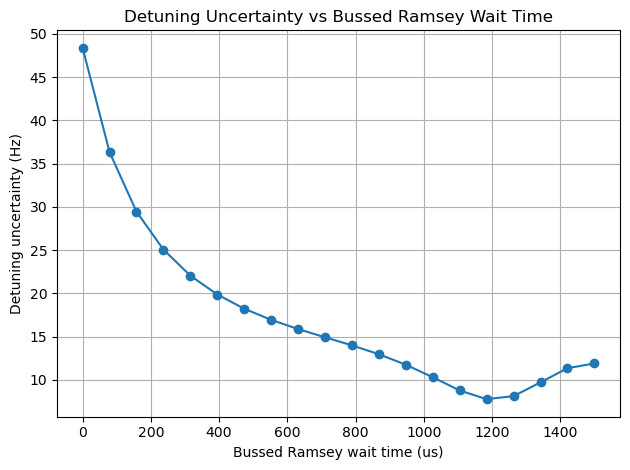

In [154]:
import matplotlib.pyplot as plt

plt.figure()
plt.plot(bussed_Ramsey_waits, sigma_det_list, marker='o')
plt.xlabel('Bussed Ramsey wait time (us)')
plt.ylabel('Detuning uncertainty (Hz)')
plt.title('Detuning Uncertainty vs Bussed Ramsey Wait Time')
plt.grid()
plt.tight_layout()
plt.show()

# Sensitivity VS Uncertainty

In [139]:
list_of_transitions = [[0, 2, 2], [0, 3, 0], [0, 3, 2], [0, 3, 1], [0, 3, -1], [0, 4, 1], [0, 4, 0], [0, 4, -1], [0, 4, -2], [0, 2, -2], [0, 2, -1], [0, 2, 1], [0, 1, -1], [0, 1, 1]]
list_of_ramsey_times = 0.5*np.array([1100, 2300, 1100, 1300, 5000, 4000, 1500, 1250, 1100, 1500, 1500, 1500, 1100, 1100])
sensitivities_path=r"Z:\Lab Data\Phase_and_freq_correction_180Hz\sensitivities_4p2079.txt" 
sens_matrix = np.loadtxt(sensitivities_path, delimiter=",")
# sens_list = get_pi_times_from_matrix(transition_pair, sens_matrix)
sens_list = []
sigma_det_list = []
for transition, times in zip(list_of_transitions, list_of_ramsey_times):
    sens_list.append(get_pi_times_from_matrix([transition], sens_matrix)[0])
    print(f"  Wait time: {times} us, Transition: {transition}, Sensitivity: {sens_list[-1]:.3f} MHz/G")
    fitted_detuning, sigma_detuning, grad, sigma_r = propagated_detuning_uncertainty(ket_data=ket_data, phase_list=phase_list,transition_pair=[transition, [0, 2, 0]], T_wait_bussed_ramsey=times, n_shots=100, consider_line = True)
    # print(f"    Fitted detuning (Hz): {fitted_detuning / (2 * np.pi):.2f}")
    print(f"    Detuning uncertainty (Hz): {sigma_detuning / (2 * np.pi):.2f}")
    sigma_det_list.append(sigma_detuning / (2 * np.pi))


  Wait time: 550.0 us, Transition: [0, 2, 2], Sensitivity: 3.257 MHz/G
    Detuning uncertainty (Hz): 15.89
  Wait time: 1150.0 us, Transition: [0, 3, 0], Sensitivity: 1.037 MHz/G
    Detuning uncertainty (Hz): 7.96
  Wait time: 550.0 us, Transition: [0, 3, 2], Sensitivity: 3.202 MHz/G
    Detuning uncertainty (Hz): 16.35
  Wait time: 650.0 us, Transition: [0, 3, 1], Sensitivity: 2.139 MHz/G
    Detuning uncertainty (Hz): 13.44
  Wait time: 2500.0 us, Transition: [0, 3, -1], Sensitivity: -0.097 MHz/G
    Detuning uncertainty (Hz): 3.71
  Wait time: 2000.0 us, Transition: [0, 4, 1], Sensitivity: -0.199 MHz/G
    Detuning uncertainty (Hz): 4.56
  Wait time: 750.0 us, Transition: [0, 4, 0], Sensitivity: -1.387 MHz/G
    Detuning uncertainty (Hz): 11.21
  Wait time: 625.0 us, Transition: [0, 4, -1], Sensitivity: -2.466 MHz/G
    Detuning uncertainty (Hz): 14.11
  Wait time: 550.0 us, Transition: [0, 4, -2], Sensitivity: -3.420 MHz/G
    Detuning uncertainty (Hz): 16.99
  Wait time: 750.0 u

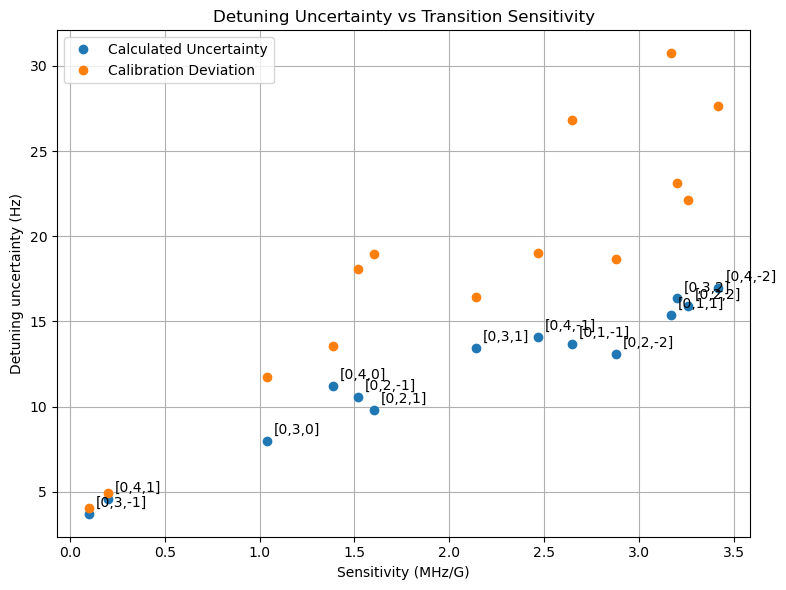

In [147]:
plt.figure(figsize=(8,6))

plt.plot(np.abs(sens_list), np.array(sigma_det_list), 'o', label='Calculated Uncertainty') 

# can you  annotate points with transition labels?
for i, transition in enumerate(list_of_transitions):
    plt.annotate(f"[{transition[0]},{transition[1]},{transition[2]}]", (np.abs(sens_list[i]), sigma_det_list[i]), textcoords="offset points", xytext=(5,5), ha='left')

sens_data = np.array([2.64786667, 3.16843916, 2.87704504, 1.51802653, 1.60415729,
       3.25693033, 0.09692457, 1.03669733, 2.13864045, 3.20159923,
       3.42010053, 2.4661911 , 1.38675807, 0.19865748])

deviation = np.array([26.8008877 , 30.73787883, 18.69236793, 18.06647591, 18.93568599,
       22.105553  ,  4.0443694 , 11.76102557, 16.42239178, 23.10726554,
       27.64680068, 19.00928243, 13.55282008,  4.91579299])

plt.plot(sens_data, deviation, 'o', label='Calibration Deviation')

plt.xlabel('Sensitivity (MHz/G)')
plt.ylabel('Detuning uncertainty (Hz)')
plt.title('Detuning Uncertainty vs Transition Sensitivity')
plt.grid()
plt.tight_layout()
plt.legend()
plt.show()
